In [1]:
# Import utility functions
import sys
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import requests
import json
sys.path.append('..')  # Add parent directory to path

# Import from local utility modules
from lvt_utils import (model_split_rate_tax, calculate_current_tax, ensure_geodataframe, 
                       categorize_property_type, calculate_category_tax_summary, print_category_tax_summary)
from census_utils import (get_census_data_with_boundaries, match_parcels_to_demographics, 
                          create_demographic_summary, calculate_median_percentage_by_quintile, match_to_census_blockgroups)
from viz import (create_scatter_plot, plot_comparison, calculate_correlations, weighted_median, 
                 create_quintile_summary, plot_quintile_analysis, create_property_category_chart, 
                 create_map_visualization, calculate_block_group_summary, filter_data_for_analysis)

# Control variable for data scraping
data_scrape = 0  # Set to 1 to scrape new data, 0 to use existing data

print("✅ Utility functions imported from LVTShift modules")

✅ Utility functions imported from LVTShift modules


In [2]:
import glob
from datetime import datetime

# Create data directory if it doesn't exist
data_dir = "data/denver/"
os.makedirs(data_dir, exist_ok=True)

In [3]:
import geopandas as gpd
import pandas as pd

gdf_parcels = gpd.read_parquet("data/denver/1-assemble-universe.parquet")
#df_mills = pd.read_csv("data/denver/denver_millage_2024.csv")
df_mills = pd.read_csv("data/denver/denver_just_city_county_millage_2024.csv")

In [4]:
land_to_impr_ratio = 2.0

In [5]:
df_mills

,tax_district,district_name,mills_all,mills_school,mills_local
0,072E,North Pecos Water & Sanitation District,26.891,0,26.891
1,077G,Holly Hills Water & Sanitation District,26.891,0,26.891
2,082B,Valley Sanitation District,26.891,0,26.891
3,101C,Clear Creek Valley Water & Sanitation District,26.891,0,26.891
4,111H,Goldsmith Metropolitan District (debt),26.891,0,26.891
...,...,...,...,...,...
179,506B,474B (RiNo BID – Commercial),26.891,0,26.891
180,486C,City & County of Denver,26.891,0,26.891
181,504B,City & County of Denver,26.891,0,26.891
182,505A,Ballpark GID (0 mills),26.891,0,26.891


In [6]:
gdf = gdf_parcels.merge(df_mills, on="tax_district", how="left")

In [7]:
# Assessment formula is:

# (Actual Value * Assessed Rate) - Exemption = Taxable Value
# (Taxable Value) * Millage = Taxes Owed

# 2025 Assessment Rates

r_rate_local   = 0.0625 # residential-improved, non-school local government
r_rate_schools = 0.0705 # residential-improved, schools only
o_rate         = 0.27   # all other, all local governments

In [8]:
for f in ["exempt_school_value", "exempt_local_value", "assr_market_value", "assr_land_value", "assr_impr_value"]:
    gdf[f] = gdf[f].fillna(0.0)

In [9]:
# Guarantee land+impr values always add up to market value:

gdf["assr_impr_value"] = gdf["assr_market_value"] - gdf["assr_land_value"]

In [10]:
gdf["is_tax_class_res"] = gdf["model_group"].eq("single_family") & gdf["is_vacant"].eq(False)

In [11]:
gdf["is_vacant"] = (
    (~gdf["bldg_area_finished_sqft"].gt(0) & ~gdf["assr_impr_value"].gt(0)) |
    (gdf["model_group"].eq("single_family") & (gdf["assr_impr_value"]/gdf["assr_market_value"]).lt(0.1))
)

In [12]:
gdf["PROPERTY_CATEGORY"] = np.where(gdf["is_vacant"], "vacant_land", gdf["model_group"])

In [13]:
# Calculate taxable values for three cases:
# 1. Residential-improved for schools
# 2. Residential-improved for all other local government
# 3. All other categories for all local governments

# Calculate assessed values and subtract exemptions
gdf["taxable_value_r_schools"] = ((gdf["assr_market_value"]) * r_rate_schools)
gdf["taxable_value_r_local"] = ((gdf["assr_market_value"]) * r_rate_local)
gdf["taxable_value_other"] = ((gdf["assr_market_value"]) * o_rate)

# Calculate millage rates
gdf["taxes_r_schools"] = gdf["taxable_value_r_schools"] * gdf["mills_school"] * 0.001
gdf["taxes_r_local"] = gdf["taxable_value_r_local"] * gdf["mills_local"] * 0.001
gdf["taxes_other"] = gdf["taxable_value_other"] * gdf["mills_all"] * 0.001

# Assign property tax based on class
gdf["property_tax"] = 0.0
gdf.loc[gdf["is_tax_class_res"].eq(True), "property_tax"] = gdf["taxes_r_schools"].astype(float) + gdf["taxes_r_local"].astype(float)
gdf.loc[gdf["is_tax_class_res"].eq(False), "property_tax"] = gdf["taxes_other"].astype(float)

gdf["property_tax"].sum()

np.float64(1319227769.8538222)

In [14]:
for word in ["land", "impr", "market"]:
    gdf[f"taxable_value_{word}_school"] = np.where(
        gdf["is_tax_class_res"], 
        gdf[f"assr_{word}_value"] * r_rate_schools, 
        gdf[f"assr_{word}_value"] * o_rate
    )
    gdf[f"taxable_value_{word}_nonschool"] = np.where(
        gdf["is_tax_class_res"], 
        gdf[f"assr_{word}_value"] * r_rate_local, 
        gdf[f"assr_{word}_value"] * o_rate
    )

In [15]:
# Exempt amount seems to be calculated from
# some unstated amount of the base value, times the assessment rate of local/school, respectively
# This means we can back out the exempted amount of actual value by dividing

# Divide the exemption amount by the appropriate tax rate to get the amount of actual value exempted
gdf["exempt_local_total"] = gdf["exempt_local_value"] / r_rate_local
gdf["exempt_school_total"] = gdf["exempt_school_value"] / r_rate_schools

# Get the difference between exempted value and actual value per class
gdf["exempt_diff_local"] = gdf["assr_market_value"] - gdf["exempt_local_total"]
gdf["exempt_diff_school"] = gdf["assr_market_value"] - gdf["exempt_school_total"]

# It seems fine to just use the local rate, because both _local and _school settle on similar figures when we reverse the operation

# Get the difference as percentage and absolute percentage of actual value
gdf["ex_diff_perc"] = (gdf["exempt_diff_local"]/gdf["assr_market_value"])
gdf["ex_diff_abs_perc"] = (gdf["exempt_diff_local"]/gdf["assr_market_value"]).abs()

# Assign amount exempted
gdf["exempt_perc"] = 0.0

# If the exempted value is higher than actual value, count that as fully exempt
gdf.loc[gdf["ex_diff_perc"].le(0), "exempt_perc"] = 1.0

# If the exempted value is lower than actual value, count it as partially exempt
gdf.loc[
    gdf["exempt_perc"].lt(1.0) &
    gdf["ex_diff_perc"].gt(0), "exempt_perc"
] = gdf["exempt_local_total"] / gdf["assr_market_value"]

# Anything with 100% exempt is flagged with a binary
gdf["is_exempt"] = False
gdf.loc[gdf["exempt_perc"].ge(1.0), "is_exempt"] = True
gdf.loc[gdf["assr_land_value"].eq(0.0) & gdf["assr_impr_value"].eq(0.0), "is_exempt"] = True

gdf["exemptions"] = gdf["assr_market_value"] * gdf["exempt_perc"]

#gdf.loc[gdf["PROPERTY_CATEGORY"].eq("single_family"), "exemptions"] = gdf["exemptions"] + 100000
#gdf.loc[gdf["PROPERTY_CATEGORY"].eq("vacant_land"), "exemptions"] = 0.0

# gdf["is_exempt"] = False
# gdf["exempt_perc"] = 0.0
# gdf["ex_diff_perc"] = 0.0
# gdf["exemptions"] = 0.0

from policy_analysis import analyze_property_values_by_category

analyze_property_values_by_category(gdf, "PROPERTY_CATEGORY", "taxable_value_land_nonschool", "taxable_value_impr_nonschool", "exemptions", "is_exempt")

,PROPERTY_CATEGORY,total_land_value,property_count,total_improvement_value,improvement_land_ratio,total_exemptions,non_exempt_land_value,non_exempt_improvement_value,non_exempt_improvement_land_ratio,fully_exempt_count
2,commercial,3.934577e+09,6633,8.830809e+09,2.244411,11075152660.0,3103026566.0,6525192183.0,2.102848,970
5,industrial,2.802641e+09,4497,3.272304e+09,1.167579,8651410580.0,1763415981.0,1972063962.0,1.11832,897
9,single_family,2.512865e+09,127358,3.893208e+09,1.549310,307919240.0,2503866815.25,3881474540.25,1.550192,311
10,vacant_land,1.696290e+09,19687,1.005996e+07,0.005931,2349200100.0,1066677817.25,9751612.75,0.009142,7797
1,apartment,1.375644e+09,1928,8.251518e+09,5.998296,3075711520.0,1232341299.0,7536127580.0,6.115293,171
8,rowhome,1.328846e+09,29743,3.975906e+09,2.991999,18920240.0,1324200447.0,3975220287.0,3.001978,223
3,condo,8.923999e+08,45394,4.591066e+09,5.144629,969480.0,892149093.0,4591054917.0,5.146062,799
4,duplex,3.226370e+08,2903,2.314904e+08,0.717495,116238980.0,304199145.0,218446200.0,0.718103,100
6,multi_family,2.456892e+08,1764,2.711633e+08,1.103684,128177220.0,226222956.0,255604680.0,1.129879,67
0,UNKNOWN,1.314941e+08,157,4.540234e+08,3.452803,1333093520.0,54238221.0,165793338.0,3.056762,70


In [16]:
gdf[
    gdf["PROPERTY_CATEGORY"].eq("UNKNOWN") &
    gdf["is_exempt"]
][["address","assr_market_value","assr_land_value","assr_impr_value","bldg_area_finished_sqft","exemptions"]].sort_values(by="assr_market_value", ascending=False)

,address,assr_market_value,assr_land_value,assr_impr_value,bldg_area_finished_sqft,exemptions
84829,2700 W 17TH AVE,614841100.0,65054900.0,549786200.0,1721086.0,614841100.0
10921,3600 N HAVANA ST,139205700.0,33299900.0,105905800.0,880442.0,139205700.0
113795,490 W COLFAX AVE,120503800.0,20928900.0,99574900.0,434935.0,120503800.0
113326,1331 N CHEROKEE ST,86307800.0,23416000.0,62891800.0,269234.0,86307800.0
10923,10500 E SMITH RD,64309400.0,660200.0,63649200.0,390822.0,64309400.0
...,...,...,...,...,...,...
26,19182 E 62ND AVE,352200.0,180400.0,171800.0,2430.0,352200.0
80784,20309 E 48TH PL,56500.0,56500.0,0.0,4452.0,56500.0
41322,5225 N ADAMS ST,0.0,0.0,0.0,1632.0,0.0
108919,1060 E COLFAX AVE,0.0,0.0,0.0,11277.0,0.0


In [17]:
gdf = gdf[gdf["is_exempt"].eq(False)].copy()

In [18]:
# Exclude tiny categories
vcs = gdf["PROPERTY_CATEGORY"].value_counts()
gdf = gdf[
    gdf["PROPERTY_CATEGORY"].isin(vcs[vcs > 50].index.tolist()) &
    gdf["PROPERTY_CATEGORY"].ne("UNKNOWN")
].copy()

In [19]:
# Calculate current tax:
field_s = f"taxable_value_market_school"
field_ns = f"taxable_value_market_nonschool"



In [20]:
gdf.groupby("PROPERTY_CATEGORY")[["assr_land_value","assr_impr_value","exemptions"]].sum()

,assr_land_value,assr_impr_value,exemptions
PROPERTY_CATEGORY,,,
apartment,4733728500.0,28687135800.0,840421120.0
commercial,11612760600.0,25099375500.0,508079360.0
condo,3304646300.0,17003907600.0,390880.0
duplex,1143434700.0,821356400.0,28706080.0
industrial,6544257700.0,7317746600.0,13619680.0
multi_family,849506800.0,962764900.0,26180320.0
rowhome,4907167200.0,14723592800.0,2448640.0
single_family,40095373800.0,62152472900.0,91277440.0
vacant_land,8873269900.0,155321700.0,84072000.0


In [21]:
# Calculate split-rate tax:
field_market_s = f"taxable_value_market_school"
field_land_s = f"taxable_value_land_school"
field_impr_s = f"taxable_value_impr_school"

field_market_ns = f"taxable_value_market_nonschool"
field_land_ns = f"taxable_value_land_nonschool"
field_impr_ns = f"taxable_value_impr_nonschool"


In [22]:
gdfs = []

for tax_district in gdf["tax_district"].unique():
    gdf_td = gdf[gdf["tax_district"].eq(tax_district)].copy()

    current_tax_s, _, gdf_s = calculate_current_tax(gdf_td, field_s, "mills_school", "exemptions", "is_exempt")
    current_tax_ns, _, gdf_ns = calculate_current_tax(gdf_td, field_ns, "mills_local", "exemptions", "is_exempt")
    
    current_tax_total = current_tax_s + current_tax_ns
    gdf_td["current_tax_school"] = gdf_s["current_tax"]
    gdf_td["current_tax_nonschool"] = gdf_ns["current_tax"]
    gdf_td["current_tax"] = gdf_td["current_tax_school"] + gdf_td["current_tax_nonschool"]
    
    land_mills_s, impr_mills_s, new_tax_s, gdf_new_s = model_split_rate_tax(
        df=gdf_td, 
        land_value_col=field_land_s, 
        improvement_value_col=field_impr_s, 
        current_revenue=current_tax_s,
        land_improvement_ratio=land_to_impr_ratio,
        exemption_col="exemptions",
        exemption_flag_col="is_exempt"
    )
    
    land_mills_ns, impr_mills_ns, new_tax_ns, gdf_new_ns = model_split_rate_tax(
        df=gdf_td, 
        land_value_col=field_land_ns, 
        improvement_value_col=field_impr_ns, 
        current_revenue=current_tax_ns,
        land_improvement_ratio=land_to_impr_ratio,
        exemption_col="exemptions",
        exemption_flag_col="is_exempt"
    )
    
    new_tax_total = new_tax_s + new_tax_ns
    gdf_td["new_tax_school"] = gdf_new_s["new_tax"]
    gdf_td["new_tax_nonschool"] = gdf_new_ns["new_tax"]
    gdf_td["new_tax"] = gdf_td["new_tax_school"] + gdf_td["new_tax_nonschool"]
    
    gdf_td["land_tax_school"] = gdf_new_s["land_tax"]
    gdf_td["land_tax_nonschool"] = gdf_new_ns["land_tax"]
    gdf_td["land_tax"] = gdf_td["land_tax_school"] + gdf_td["land_tax_nonschool"]
    
    gdf_td["improvement_tax_school"] = gdf_new_s["improvement_tax"]
    gdf_td["improvement_tax_nonschool"] = gdf_new_ns["improvement_tax"]
    gdf_td["improvement_tax"] = gdf_td["improvement_tax_school"] + gdf_td["improvement_tax_nonschool"]

    gdfs.append(gdf_td)

gdf = pd.concat(gdfs)

print("")
print(f" SCHOOL CURR TAX  = {gdf['current_tax_school'].sum():>20,.2f}")
print(f"NSCHOOL CURR TAX  = {gdf['current_tax_nonschool'].sum():>20,.2f}")
print(f"  TOTAL CURR TAX  = {gdf['current_tax'].sum():>20,.2f}")
print("")
print(f" SCHOOL NEW   TAX = {gdf['new_tax_school'].sum():>20,.2f}")
print(f"NSCHOOL NEW   TAX = {gdf['new_tax_nonschool'].sum():>20,.2f}")
print(f"  TOTAL NEW   TAX = {gdf['new_tax'].sum():>20,.2f}")

display(gdf)


 SCHOOL CURR TAX  =                 0.00
NSCHOOL CURR TAX  =     1,112,777,441.27
  TOTAL CURR TAX  =     1,112,777,441.27

 SCHOOL NEW   TAX =                 0.00
NSCHOOL NEW   TAX =     1,112,777,441.27
  TOTAL NEW   TAX =     1,112,777,441.27


,RES_ABOVE_GRADE_AREA,COM_ORIG_YEAR_BUILT,COM_GROSS_AREA,SCHEDNUM,RES_ORIG_YEAR_BUILT,key,neighborhood,zoning,zoning_type,zoning_desc,...,current_tax,new_tax_school,new_tax_nonschool,new_tax,land_tax_school,land_tax_nonschool,land_tax,improvement_tax_school,improvement_tax_nonschool,improvement_tax
0,NaN,NaN,NaN,0010200140000,NaN,10200140000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,...,0.726057,0.0,1.306815,1.306815,0.0,1.306815,1.306815,0.0,0.0,0.0
1,NaN,1996.0,55590.0,0010200141000,NaN,10200141000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,...,79950.492612,0.0,81836.049188,81836.049188,0.0,19770.810622,19770.810622,0.0,62065.238566,62065.238566
2,NaN,1997.0,38804.0,0010200144000,NaN,10200144000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,...,55592.006319,0.0,58973.313261,58973.313261,0.0,17887.689589,17887.689589,0.0,41085.623673,41085.623673
3,NaN,1997.0,42481.0,0010200145000,NaN,10200145000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,...,42720.467823,0.0,46769.61738,46769.61738,0.0,16647.521747,16647.521747,0.0,30122.095633,30122.095633
7,NaN,1998.0,6949.0,0010200153000,NaN,10200153000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,...,9013.997655,0.0,11392.1635,11392.1635,0.0,6560.213452,6560.213452,0.0,4831.950048,4831.950048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240017,1202.0,NaN,NaN,0914502130130,1998.0,914502130130,Marston,R-2-A,Residential,Former Chapter 59 Zone,...,3050.891514,0.0,3083.431673,3083.431673,0.0,666.298757,666.298757,0.0,2417.132917,2417.132917
240018,1498.0,NaN,NaN,0914502132132,1997.0,914502132132,Marston,R-2-A,Residential,Former Chapter 59 Zone,...,3721.042125,0.0,3687.551273,3687.551273,0.0,666.298757,666.298757,0.0,3021.252516,3021.252516
240019,1517.0,NaN,NaN,0914502133133,1997.0,914502133133,Marston,R-2-A,Residential,Former Chapter 59 Zone,...,4081.166397,0.0,4012.191925,4012.191925,0.0,666.298757,666.298757,0.0,3345.893168,3345.893168
240020,1871.0,NaN,NaN,0914502134134,1997.0,914502134134,Marston,R-2-A,Residential,Former Chapter 59 Zone,...,4093.509366,0.0,4023.318721,4023.318721,0.0,666.298757,666.298757,0.0,3357.019965,3357.019965


In [23]:
# Calculate comprehensive tax impact summary by property category
category_summary = calculate_category_tax_summary(
    df=gdf,
    category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax_nonschool',
    new_tax_col='new_tax_nonschool',
    pct_threshold=10.0
)

# Print formatted summary
print_category_tax_summary(
    summary_df=category_summary,
    title=f"{land_to_impr_ratio:.0f}:1 Split-Rate Tax Impact by Property Category - Denver, CO",
    pct_threshold=10.0
)

# Display the detailed summary table
display(category_summary)



2:1 Split-Rate Tax Impact by Property Category - Denver, CO
     Category  Count Total Tax Δ ($) Total Δ (%) Mean Δ ($) Median Δ ($) Avg % Δ Median % Δ % Parcels > +10% % Parcels < -10%
single_family 127047     $12,219,441        7.1%        $96          $22    6.0%       2.2%            33.4%            12.1%
        condo  44595    $-14,528,649       -9.9%      $-326        $-308  -10.5%     -13.0%             5.2%            63.5%
      rowhome  29520     $-4,914,086       -3.4%      $-166        $-298   -4.1%      -6.8%            16.8%            41.1%
  vacant_land  11890     $13,637,870       47.1%     $1,147         $594   50.6%      52.0%            97.7%             0.0%
   commercial   5663      $2,580,032        1.0%       $456       $1,269   18.3%      16.0%            58.0%            12.0%
   industrial   3600     $10,961,976       10.9%     $3,045         $951   15.0%      10.8%            51.2%             8.9%
       duplex   2803      $2,862,175       20.4%     $1,0

,PROPERTY_CATEGORY,total_tax_change_dollars,property_count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,total_current_tax,total_new_tax,pct_increase_gt_threshold,pct_decrease_gt_threshold,total_tax_change_pct
7,single_family,12219440.870022,127047,96.180475,22.380699,6.013040,2.186377,171708214.39075,183927655.260772,33.436445,12.121498,7.116399
2,condo,-14528649.451455,44595,-325.790996,-308.316458,-10.505149,-12.962460,147448839.03291,132920189.581455,5.173226,63.509362,-9.85335
6,rowhome,-4914086.053085,29520,-166.46633,-298.0871,-4.109236,-6.781234,142506722.957994,137592636.904909,16.849593,41.148374,-3.448319
8,vacant_land,13637870.39684,11890,1147.003398,593.610458,50.601736,51.988513,28946263.80213,42584134.19897,97.746005,0.000000,47.114441
1,commercial,2580031.764863,5663,455.59452,1268.510848,18.339632,15.968584,258912430.379359,261492462.144222,57.972806,11.954794,0.996488
4,industrial,10961975.711357,3600,3044.993253,950.990437,14.991456,10.776966,100450791.147213,111412766.85857,51.194444,8.944444,10.912782
3,duplex,2862174.909933,2803,1021.111277,742.574398,16.504249,14.911398,14054455.972395,16916630.882328,56.831966,5.636818,20.364893
0,apartment,-24353013.769244,1757,-13860.565606,-3232.847041,-6.856352,-9.770602,235792896.625189,211439882.855945,6.829824,48.890154,-10.328137
5,multi_family,1534255.620771,1697,904.098775,459.508454,11.082507,8.561054,12956826.959676,14491082.580447,47.790218,7.307012,11.841291


In [24]:
# Calculate tax changes
gdf['tax_change'] = gdf['new_tax'] - gdf['current_tax']
gdf['tax_change_pct'] = (gdf['tax_change'] / gdf['property_tax']) * 100
gdf["tax_change_pct"] = gdf["tax_change_pct"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Add land price per square foot
gdf['land_price_per_sqft'] = gdf['assr_land_value'] / gdf['land_area_sqft']

In [25]:
gdf[
    gdf["PROPERTY_CATEGORY"].eq("single_family")
][[
    "address",
    "assr_land_value",
    "assr_impr_value",
    "current_tax",
    "new_tax",
    "land_tax",
    "improvement_tax",
    "tax_change_pct",
    "mills_school",
    "mills_local",
    "mills_all",
]].sort_values(by="tax_change_pct", ascending=False)

,address,assr_land_value,assr_impr_value,current_tax,new_tax,land_tax,improvement_tax,tax_change_pct,mills_school,mills_local,mills_all
65884,3601 WAZEE ST,937500.0,181600.0,1880.857381,3016.689659,2750.312706,266.376953,60.38907,0,26.891,26.891
219301,3380 S HOLLY PL,657300.0,109700.0,1289.087313,2018.130406,1862.693415,155.43699,56.554982,0,26.891,26.891
90679,2361 CURTIS ST,931200.0,127000.0,1778.503512,2592.961543,2427.431174,165.530369,45.79457,0,26.891,26.891
163295,1290 S YORK ST,1197000.0,133000.0,2235.314375,3229.798878,3059.809463,169.989415,44.489693,0,26.891,26.891
132582,22 N PENNSYLVANIA ST,535400.0,59500.0,999.840994,1444.654401,1368.606505,76.047896,44.488415,0,26.891,26.891
...,...,...,...,...,...,...,...,...,...,...,...
37239,14287 E 51ST AVE,0.0,273800.0,460.172237,349.948133,0.0,349.948133,-23.952793,0,26.891,26.891
54930,4710 N LINCOLN ST,0.0,234600.0,394.289288,299.84599,0.0,299.84599,-23.952793,0,26.891,26.891
186450,984 N SPRUCE CT,0.0,220400.0,370.423525,281.696744,0.0,281.696744,-23.952793,0,26.891,26.891
149986,3413 W ALASKA PL,0.0,421100.0,707.737506,538.214605,0.0,538.214605,-23.952793,0,26.891,26.891


In [26]:
# Save the processed data with today's date in the filename
today_str = datetime.now().strftime("%Y-%m-%d")
save_path = f"{data_dir}denver_parcels_processed_{today_str}.parquet"
gdf.to_parquet(save_path)
print(f"💾 Saved processed data to {save_path}")

💾 Saved processed data to data/denver/denver_parcels_processed_2025-12-17.parquet


In [27]:
print(f"\n📊 Dataset Overview:")
print(f"Total parcels: {len(gdf):,}")
print(f"Columns: {len(gdf.columns)}")
print(f"Geometry type: {gdf.geometry.geom_type.iloc[0]}")

# Display key statistics
total_current_revenue = gdf['current_tax'].sum()
print(f"\n💰 Current Tax System:")
print(f"Total annual revenue: ${total_current_revenue:,.2f}")
print(f"Mean property tax: ${gdf['current_tax'].mean():,.2f}")
print(f"Median property tax: ${gdf['current_tax'].median():.2f}")



📊 Dataset Overview:
Total parcels: 228,572
Columns: 97
Geometry type: MultiPolygon

💰 Current Tax System:
Total annual revenue: $1,112,777,441.27
Mean property tax: $4,868.39
Median property tax: $1541.42


In [28]:
# Ensure proper GeoDataFrame format
gdf = ensure_geodataframe(gdf)

gdf["Lvalue"] = gdf["assr_land_value"]
gdf["Fvalue"] = gdf["assr_market_value"]

# Display property statistics
print(f"🏠 Property Statistics:")
print(f"Total parcels    : {len(gdf):10,}")
print(f"Vacant parcels   : {gdf['is_vacant'].sum():10,} ({gdf['is_vacant'].sum()/len(gdf)*100:4.1f}%)")

print("\n📋 Property Categories (Standardized):")
category_counts = gdf['PROPERTY_CATEGORY'].value_counts()
for category, count in category_counts.head(10).items():
    pct = count / len(gdf) * 100
    print(f"  {category:25}: {count:10,} ({pct:4.1f}%)")

print("\n🏗️ Property Value Statistics:")
print(f"Mean land        : ${gdf['Lvalue'].mean():20,.2f}")
print(f"Mean improvement : ${gdf['Fvalue'].mean():20,.2f}")
print(f"Total land       : ${gdf['Lvalue'].sum():20,.2f}")
print(f"Total improvement: ${gdf['Fvalue'].sum():20,.2f}")


🏠 Property Statistics:
Total parcels    :    228,572
Vacant parcels   :     11,890 ( 5.2%)

📋 Property Categories (Standardized):
  single_family            :    127,047 (55.6%)
  condo                    :     44,595 (19.5%)
  rowhome                  :     29,520 (12.9%)
  vacant_land              :     11,890 ( 5.2%)
  commercial               :      5,663 ( 2.5%)
  industrial               :      3,600 ( 1.6%)
  duplex                   :      2,803 ( 1.2%)
  apartment                :      1,757 ( 0.8%)
  multi_family             :      1,697 ( 0.7%)

🏗️ Property Value Statistics:
Mean land        : $          359,029.74
Mean improvement : $        1,045,569.10
Total land       : $   82,064,145,500.00
Total improvement: $  238,987,819,700.00


In [29]:
# Calculate current property taxes
total_revenue = gdf["current_tax"].sum()

print(f"Calculated total current tax revenue: ${total_revenue:,.2f}")

Calculated total current tax revenue: $1,112,777,441.27


In [30]:
import pandas as pd
pd.set_option('display.max_columns', None)
display(gdf.head())

,RES_ABOVE_GRADE_AREA,COM_ORIG_YEAR_BUILT,COM_GROSS_AREA,SCHEDNUM,RES_ORIG_YEAR_BUILT,key,neighborhood,zoning,zoning_type,zoning_desc,assr_impr_value,exempt_local_value,taxable_school_value,assr_market_value,class,bldg_units,assr_land_value,key_block,taxable_local_value,key_parcel,key_appendage,city,key_map,tax_district,exempt_school_value,address,is_tax_class_res,bldg_quality_txt,bldg_quality_num,bldg_year_built,bldg_area_finished_sqft,latitude,longitude,latitude_norm,longitude_norm,land_area_gis_sqft,land_area_sqft,land_area_sqft_log,geom_rectangularity_num,geom_aspect_ratio,is_geom_triangular,geom_vertices,is_geom_complex,is_geom_elongated,is_geom_irregular,polar_radius,polar_angle,median_income,total_population,median_g_rent,median_c_rent,geometry,bldg_age_years,is_vacant,model_group,district_name,mills_all,mills_school,mills_local,PROPERTY_CATEGORY,taxable_value_r_schools,taxable_value_r_local,taxable_value_other,taxes_r_schools,taxes_r_local,taxes_other,property_tax,taxable_value_land_school,taxable_value_land_nonschool,taxable_value_impr_school,taxable_value_impr_nonschool,taxable_value_market_school,taxable_value_market_nonschool,exempt_local_total,exempt_school_total,exempt_diff_local,exempt_diff_school,ex_diff_perc,ex_diff_abs_perc,exempt_perc,is_exempt,exemptions,current_tax_school,current_tax_nonschool,current_tax,new_tax_school,new_tax_nonschool,new_tax,land_tax_school,land_tax_nonschool,land_tax,improvement_tax_school,improvement_tax_nonschool,improvement_tax,tax_change,tax_change_pct,land_price_per_sqft,Lvalue,Fvalue
0,NaN,NaN,NaN,0010200140000,NaN,10200140000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,0.0,0.0,30.0,100.0,VACANT LAND /GENERAL COMMON ELEMENTS,0.0,100.0,00,30.0,140,000,DENVER,00102,425F,0.0,6298 N TOWER RD,False,UNKNOWN,0.0,0.0,0.0,39.810850,-104.771793,0.673058,0.717656,2448.427094,2448.427094,7.803201,-0.000005,2.019533,True,4,False,False,True,1.106624e+06,27.975178,69701.0,2829.0,1750.0,1689.0,"MULTIPOLYGON (((3204628.126 1721075.188, 32045...",0.0,True,commercial,Denver Gateway Center Metropolitan District,26.891,0,26.891,vacant_land,7.05,6.25,27.0,0.0,0.168069,0.726057,0.726057,27.0,27.0,0.0,0.0,27.0,27.0,0.0,0.0,100.0,100.0,1.0,1.0,0.0,False,0.0,0.0,0.726057,0.726057,0.0,1.306815,1.306815,0.0,1.306815,1.306815,0.0,0.0,0.0,0.580758,79.987994,0.040843,100.0,100.0
1,NaN,1996.0,55590.0,0010200141000,NaN,10200141000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,9498700.0,0.0,2731490.0,11011600.0,HOTEL W/MIXED USE,<NA>,1512900.0,00,2721800.0,141,000,DENVER,00102,425F,0.0,6290 N TOWER RD,False,HOTEL W/MIXED USE,<NA>,1996.0,55590.0,39.810536,-104.771146,0.671984,0.718726,107941.022553,107941.022553,11.589340,0.955934,1.418175,False,6,False,False,False,1.106656e+06,27.972245,69701.0,2829.0,1750.0,1689.0,"MULTIPOLYGON (((3204960.299 1720804.436, 32049...",29.0,False,commercial,Denver Gateway Center Metropolitan District,26.891,0,26.891,commercial,776317.8,688225.0,2973132.0,0.0,18507.058475,79950.492612,79950.492612,408483.0,408483.0,2564649.0,2564649.0,2973132.0,2973132.0,0.0,0.0,11011600.0,11011600.0,1.0,1.0,0.0,False,0.0,0.0,79950.492612,79950.492612,0.0,81836.049188,81836.049188,0.0,19770.810622,19770.810622,0.0,62065.238566,62065.238566,1885.556576,2.358405,14.015987,1512900.0,11011600.0
2,NaN,1997.0,38804.0,0010200144000,NaN,10200144000,DIA,GTWY,Commercial Mixed Use,Former Chapter 59 Zone,6287900.0,0.0,1502150.0,7656700.0,MOTEL W/MIXED USE,<NA>,1368800.0,00,1479490.0,144,000,DENVER,00102,425F,0.0,18600 E 63RD AVE,False,MOTEL W/MIXED USE,<NA>,1997.0,38804.0,39.810392,-104.769841,0.671490,0.720885,97671.892638,97671.892638,11.489369,0.882225,1.752474,False,7,False,False,False,1.106748e+06,27.968809,69701.0,2829.0,1750.0,1689.0,"MULTIPOLYGON (((3205251.32 1720681.883, 320524...",28.0,False,commercial,Denver Gateway Center Metropolitan District,26.891,0,26.891,commercial,539797.35,478543.75,2067309.0,0.0,12868.519981,55592.006319,55592.006319,369576.0,369576.0,1697733.0,1697733.0,206

In [31]:
# Calculate comprehensive tax impact summary by property category
category_summary = calculate_category_tax_summary(
    df=gdf,
    category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax',
    new_tax_col='new_tax',
    pct_threshold=10.0
)

# Print formatted summary
print_category_tax_summary(
    summary_df=category_summary,
    title=f"{land_to_impr_ratio:.0f}:1 Split-Rate Tax Impact by Property Category - Denver, CO",
    pct_threshold=10.0
)

# Display the detailed summary table
display(category_summary)



2:1 Split-Rate Tax Impact by Property Category - Denver, CO
     Category  Count Total Tax Δ ($) Total Δ (%) Mean Δ ($) Median Δ ($) Avg % Δ Median % Δ % Parcels > +10% % Parcels < -10%
single_family 127047     $12,219,441        7.1%        $96          $22    6.0%       2.2%            33.4%            12.1%
        condo  44595    $-14,528,649       -9.9%      $-326        $-308  -10.5%     -13.0%             5.2%            63.5%
      rowhome  29520     $-4,914,086       -3.4%      $-166        $-298   -4.1%      -6.8%            16.8%            41.1%
  vacant_land  11890     $13,637,870       47.1%     $1,147         $594   50.6%      52.0%            97.7%             0.0%
   commercial   5663      $2,580,032        1.0%       $456       $1,269   18.3%      16.0%            58.0%            12.0%
   industrial   3600     $10,961,976       10.9%     $3,045         $951   15.0%      10.8%            51.2%             8.9%
       duplex   2803      $2,862,175       20.4%     $1,0

,PROPERTY_CATEGORY,total_tax_change_dollars,property_count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,total_current_tax,total_new_tax,pct_increase_gt_threshold,pct_decrease_gt_threshold,total_tax_change_pct
7,single_family,12219440.870022,127047,96.180475,22.380699,6.013040,2.186377,171708214.39075,183927655.260772,33.436445,12.121498,7.116399
2,condo,-14528649.451455,44595,-325.790996,-308.316458,-10.505149,-12.962460,147448839.03291,132920189.581455,5.173226,63.509362,-9.85335
6,rowhome,-4914086.053085,29520,-166.46633,-298.0871,-4.109236,-6.781234,142506722.957994,137592636.904909,16.849593,41.148374,-3.448319
8,vacant_land,13637870.39684,11890,1147.003398,593.610458,50.601736,51.988513,28946263.80213,42584134.19897,97.746005,0.000000,47.114441
1,commercial,2580031.764863,5663,455.59452,1268.510848,18.339632,15.968584,258912430.379359,261492462.144222,57.972806,11.954794,0.996488
4,industrial,10961975.711357,3600,3044.993253,950.990437,14.991456,10.776966,100450791.147213,111412766.85857,51.194444,8.944444,10.912782
3,duplex,2862174.909933,2803,1021.111277,742.574398,16.504249,14.911398,14054455.972395,16916630.882328,56.831966,5.636818,20.364893
0,apartment,-24353013.769244,1757,-13860.565606,-3232.847041,-6.856352,-9.770602,235792896.625189,211439882.855945,6.829824,48.890154,-10.328137
5,multi_family,1534255.620771,1697,904.098775,459.508454,11.082507,8.561054,12956826.959676,14491082.580447,47.790218,7.307012,11.841291


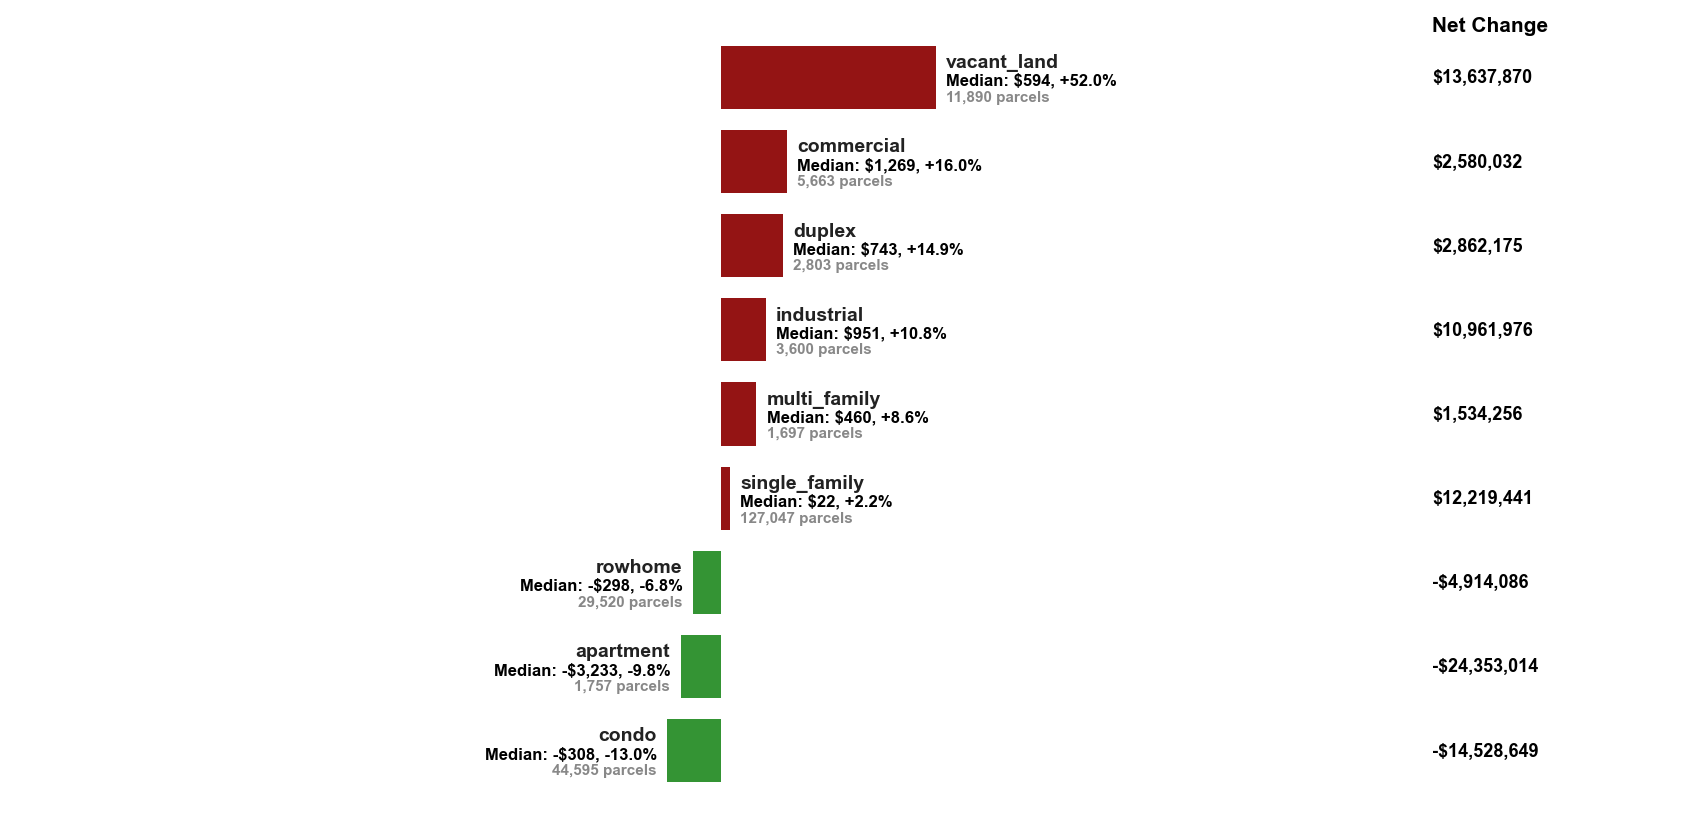

In [32]:
# Property category impact chart (Spokane style, sorted, ignore 0% median)
import matplotlib.pyplot as plt
import numpy as np

# Filter out categories where median tax change percent is exactly 0
filtered = category_summary[category_summary['median_tax_change_pct'] != 0].copy()

# Only include categories with property_count > 0 (optional, but safe)
filtered = filtered[filtered['property_count'] > 0]

# Sort by median_pct_change ascending (like Spokane)
categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = (
    filtered['total_tax_change_dollars'].tolist()
    if 'total_tax_change_dollars' in filtered.columns
    else (filtered['mean_tax_change'] * filtered['property_count']).tolist()
)

# Sort by median_pct_change ascending
sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

# Custom color: anything above 0 is dark red, below 0 is green
bar_colors = []
for val in median_pct_change:
    if val > 0:
        bar_colors.append("#8B0000")  # dark red
    else:
        bar_colors.append("#228B22")  # professional green

# Bar settings
bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120  # more padding for right column
fig, ax = plt.subplots(figsize=(17, fig_height))  # wider for right column

y = np.arange(len(categories))

# Draw bars
ax.barh(
    y, median_pct_change, color=bar_colors, edgecolor='none',
    height=bar_height, alpha=0.92, linewidth=0, zorder=2
)

# Remove all spines and ticks for a clean look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Adjusted vertical spacing
cat_offset = 0.18   # less space between category and median
med_offset = -0.03  # median just below category
count_offset = -0.23  # more space below median for parcels

# For right column: position for total tax change
max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

# Add Net Change header at the top of the right column
ax.text(
    right_col_x, len(categories) - 0.5, "Net Change", va='bottom', ha='left',
    fontsize=15, fontweight='bold', color='black', fontname='Arial'
)

for i, (cat, val, count, med_dol, tot_change) in enumerate(zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    # Format median dollar and percent change together
    if med_dol >= 0:
        med_dol_str = f"${med_dol:,.0f}"
    else:
        med_dol_str = f"-${abs(med_dol):,.0f}"
    pct_str = f"{val:+.1f}%"
    median_combo = f"Median: {med_dol_str}, {pct_str}"

    # Position: right of bar for positive, left for negative
    if val < 0:
        xpos = val - 2.5
        ha = 'right'
    else:
        xpos = val + 2.5
        ha = 'left'
    # Category name (bold, bigger)
    ax.text(
        xpos, y[i]+cat_offset, cat, va='center', ha=ha,
        fontsize=14, fontweight='bold', color='#222',
        fontname='Arial'
    )
    # Median (dollar + percent, bold, black, just below category)
    ax.text(
        xpos, y[i]+med_offset, median_combo, va='center', ha=ha,
        fontsize=12, fontweight='bold', color='black',
        fontname='Arial'
    )
    # Count (bold, smaller, below median)
    ax.text(
        xpos, y[i]+count_offset, f"{count:,} parcels", va='center', ha=ha,
        fontsize=11, fontweight='bold', color='#888',
        fontname='Arial'
    )
    # Net change column, always right-aligned in a new column, black text, no "Total:"
    if tot_change >= 0:
        tot_change_str = f"${tot_change:,.0f}"
    else:
        tot_change_str = f"-${abs(tot_change):,.0f}"
    ax.text(
        right_col_x, y[i], tot_change_str, va='center', ha='left',
        fontsize=13, fontweight='bold', color='black',
        fontname='Arial'
    )

# Set x limits for symmetry, make bars longer, and leave space for right column
ax.set_xlim(-right_col_x, right_col_x + 60)

# Remove axis labels/ticks
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()


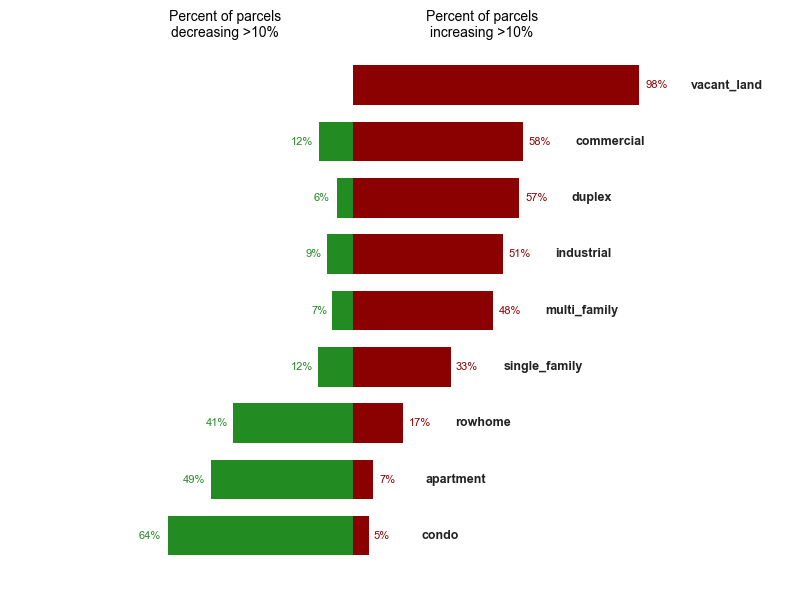

In [33]:
import matplotlib.pyplot as plt
import numpy as np
# Use output_summary to generate categories and percent increase/decrease, filtering to count > 50
# Filter to property_count > 50
summary_filtered = category_summary[category_summary['property_count'] > 50].copy()
# Sort by pct_increase_gt_threshold ascending (smallest percent increase first)
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)
categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()
# Convert to integers for display
pct_increase_int_sorted = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int_sorted = [int(round(x)) for x in pct_decrease_sorted]
y = np.arange(len(categories_sorted))
fig, ax = plt.subplots(figsize=(8, 6))
# Use specified colors
color_increase = "#8B0000"  # dark red
color_decrease = "#228B22"  # professional green
# Plot left (decrease) bars (green, to the left)
ax.barh(
    y, 
    [-v for v in pct_decrease_sorted], 
    color=color_decrease, 
    edgecolor='none', 
    height=0.7
)
# Plot right (increase) bars (red, to the right)
ax.barh(
    y, 
    pct_increase_sorted, 
    color=color_increase, 
    edgecolor='none', 
    height=0.7
)
# Add percent labels (integer, no decimals), smaller Arial font
for i, (inc, dec) in enumerate(zip(pct_increase_int_sorted, pct_decrease_int_sorted)):
    # Left side (decrease)
    if dec > 0:
        ax.text(
            -dec - 2, y[i], f"{dec}%", 
            va='center', ha='right', 
            fontsize=8, fontweight='normal', color=color_decrease, fontname='Arial'
        )
    # Right side (increase)
    if inc > 0:
        ax.text(
            inc + 2, y[i], f"{inc}%", 
            va='center', ha='left', 
            fontsize=8, fontweight='normal', color=color_increase, fontname='Arial'
        )
# Add category name at end of right bar, bold, smaller Arial, further from percent
for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(
        xpos, y[i], cat, 
        va='center', ha='left', 
        fontsize=9, fontweight='bold', color='#222', fontname='Arial'
    )
# Remove all spines, ticks, and axis lines for minimalist look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
# Remove grid, axis, and titles
ax.set_yticks([])
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('')
# Set xlim for symmetry
max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)
# --- Add custom titles above left and right bars ---
# Make the titles a little bit bigger and closer to the center
title_fontsize = 10  # increased from 8
title_color = 'black'
title_fontweight = 'normal'
title_fontname = 'Arial'
# Compute center x for both titles, but offset slightly left/right of center
title_y = len(categories_sorted) - 0.2
# Left title (above left bars), closer to center
left_title_x = -max_val * 0.45
ax.text(
    left_title_x, title_y, 
    "Percent of parcels\ndecreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)
# Right title (above right bars), closer to center
right_title_x = max_val * 0.45
ax.text(
    right_title_x, title_y, 
    "Percent of parcels\nincreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)
plt.tight_layout()
plt.show()

In [34]:
# display(
#     gdf[
#         gdf["PROPERTY_CATEGORY"].eq("duplex") &
#         gdf["tax_change_pct"].gt(40)
#     ][["taxable_value_land_nonschool","taxable_value_impr_nonschool","current_tax","new_tax","tax_change_pct"]]
# )

# #gdf.groupby("PROPERTY_CATEGORY")["tax_change_pct"].agg(["count","median"]).reset_index()

# census

In [35]:
# Get census data for Denver County, CO (Denver) - FIPS code: 08031
print("📊 Loading Census data for Denver County, CO...")
df  = gdf
try:
    census_data, census_boundaries = get_census_data_with_boundaries(
        fips_code="08031",  # Denver County, CO
        year=2022
    )
    print("GOT CENSUS DATA")
    # Set CRS for census boundaries before merging
    census_boundaries = census_boundaries.set_crs(epsg=4326)  # Assuming WGS84 coordinate system
    
    # Ensure our parcel data is in the same CRS
    if df.crs != census_boundaries.crs:
        df = df.to_crs(census_boundaries.crs)
    
    # Merge census data with our parcel boundaries
    df = match_to_census_blockgroups(
        gdf=df,
        census_gdf=census_boundaries
    )
    
    print(f"✅ Census data integration complete!")
    print(f"Number of census block groups: {len(census_boundaries)}")
    print(f"Number of census data records: {len(census_data)}")
    print(f"Number of parcels with census data: {len(df)}")
    
    # Display new columns added
    census_cols = [col for col in df.columns if col in ['median_income', 'minority_pct', 'black_pct', 'total_pop', 'census_block_group']]
    print(f"Census columns added: {census_cols}")
    
except Exception as e:
    print(f"❌ Error loading census data: {e}")


📊 Loading Census data for Denver County, CO...
❌ Error loading census data: Census API key must be provided either as parameter or in CENSUS_API_KEY environment variable


📊 Analyzing tax impacts by neighborhood income quintiles...
✅ Income quintile analysis complete
Parcels with income data: 216,973 (94.9%)


C:\Users\Lars Doucet\AppData\Local\Temp\ipykernel_21672\2231263290.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_summary = df_with_income.groupby('income_quintile').agg({


,income_quintile,tax_change_count,tax_change_mean,tax_change_median,tax_change_pct_mean,tax_change_pct_median,median_income_mean,current_tax_mean
0,Q1 (Lowest),44071,-145.14,-50.4,-0.45,-4.16,49991.42,4998.49
1,Q2,42867,-138.56,-59.12,-0.44,-5.98,75653.43,4135.27
2,Q3,43557,-100.06,-15.53,2.73,-1.39,96297.17,5041.27
3,Q4,43187,44.77,16.06,7.34,1.89,123767.63,4993.54
4,Q5 (Highest),43291,287.86,117.62,10.95,5.22,185311.27,4457.54


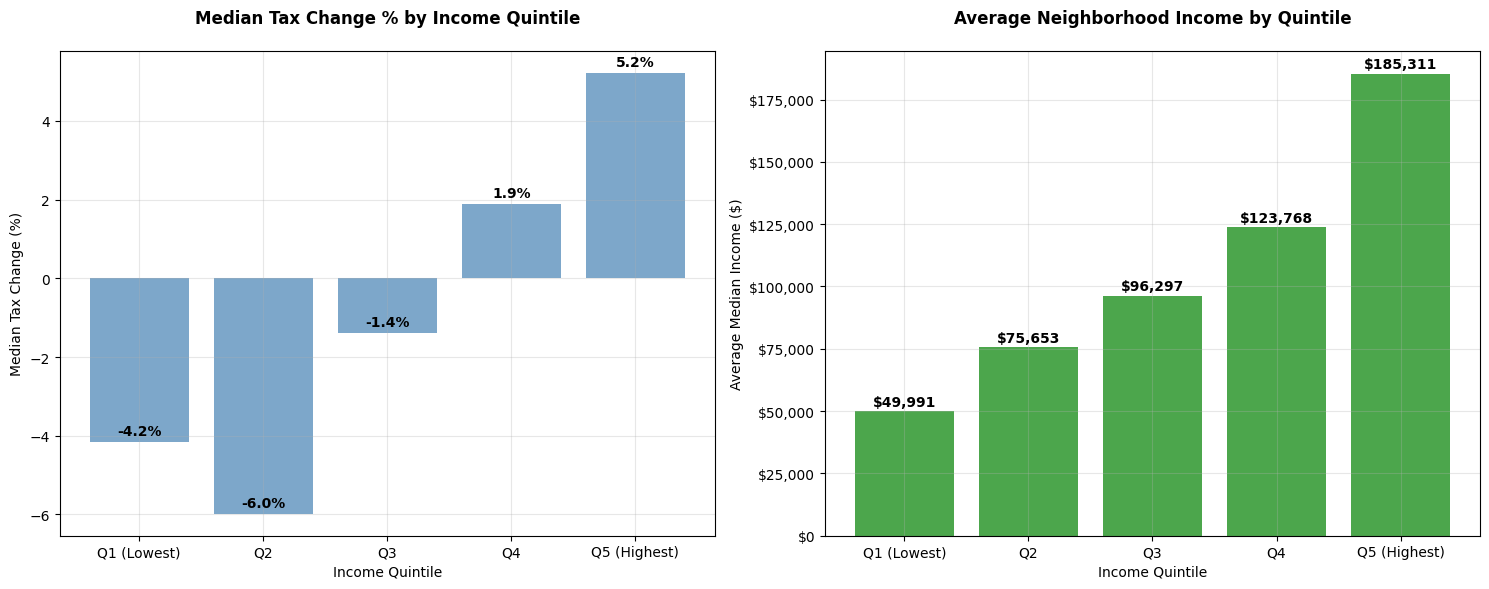

In [36]:
# Analyze tax impacts by income quintiles (similar to Spokane analysis)
print("📊 Analyzing tax impacts by neighborhood income quintiles...")

if 'median_income' in df.columns:
    # Filter out parcels with missing or non-positive income data
    df_with_income = df[(df['median_income'].notna()) & (df['median_income'] > 0)].copy()
    
    # Create income quintiles
    df_with_income['income_quintile'] = pd.qcut(
        df_with_income['median_income'], 
        5, 
        labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"]
    )
    
    # Calculate summary statistics by quintile
    quintile_summary = df_with_income.groupby('income_quintile').agg({
        'tax_change': ['count', 'mean', 'median'],
        'tax_change_pct': ['mean', 'median'],
        'median_income': 'mean',
        'current_tax': 'mean'
    }).round(2)
    
    # Flatten column names
    quintile_summary.columns = ['_'.join(col).strip() for col in quintile_summary.columns]
    quintile_summary = quintile_summary.reset_index()
    
    print(f"✅ Income quintile analysis complete")
    print(f"Parcels with income data: {len(df_with_income):,} ({len(df_with_income)/len(df)*100:.1f}%)")
    
    display(quintile_summary)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Median tax change percentage by income quintile
    quintile_data = quintile_summary.copy()
    quintile_data['median_tax_change_pct'] = quintile_data['tax_change_pct_median']
    
    bars1 = ax1.bar(
        quintile_data['income_quintile'],
        quintile_data['median_tax_change_pct'],
        color='steelblue',
        alpha=0.7
    )
    
    ax1.set_title('Median Tax Change % by Income Quintile', fontweight='bold', pad=20)
    ax1.set_ylabel('Median Tax Change (%)')
    ax1.set_xlabel('Income Quintile')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars1, quintile_data['median_tax_change_pct']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Average neighborhood income by quintile
    bars2 = ax2.bar(
        quintile_data['income_quintile'],
        quintile_data['median_income_mean'],
        color='green',
        alpha=0.7
    )
    
    ax2.set_title('Average Neighborhood Income by Quintile', fontweight='bold', pad=20)
    ax2.set_ylabel('Average Median Income ($)')
    ax2.set_xlabel('Income Quintile')
    ax2.grid(True, alpha=0.3)
    
    # Format y-axis as currency
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Add value labels on bars
    for bar, val in zip(bars2, quintile_data['median_income_mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Census income data not available - skipping quintile analysis")


📈 Creating scatter plot analysis...


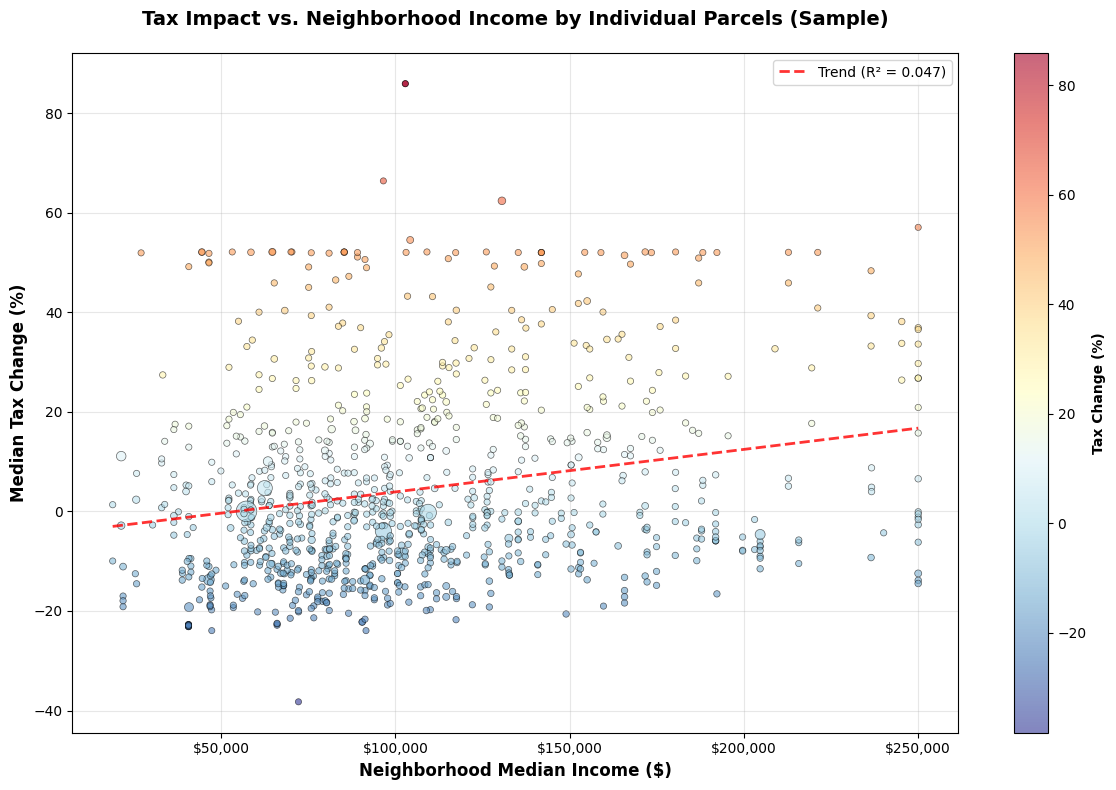

\n📊 Correlation Analysis:
- Correlation coefficient: 0.216
- R-squared: 0.047
- P-value: 4.596e-12
- Sample size: 1,000 observations
📈 Positive correlation: Higher income areas tend to have higher tax increases


In [37]:
# Scatter plot analysis: Income vs Tax Impact (similar to Spokane)
print("📈 Creating scatter plot analysis...")

if 'median_income' in df.columns and 'tax_change_pct' in df.columns:
    # Filter data for meaningful analysis
    plot_data = df[
        (df['median_income'].notna()) & 
        (df['median_income'] > 0) & 
        (df['tax_change_pct'].notna()) &
        (df['tax_change_pct'].abs() < 100)  # Remove extreme outliers
    ].copy()
    
    # Create block group level summary for cleaner visualization
    if 'census_block_group' in df.columns:
        block_summary = plot_data.groupby('census_block_group').agg({
            'median_income': 'first',  # Same for all parcels in block group
            'tax_change_pct': 'median',
            'tax_change': 'median',
            'current_tax': 'sum',
            'total_pop': 'first'
        }).reset_index()
        
        plot_data_agg = block_summary
        size_col = 'total_pop'
        title_suffix = "by Census Block Group"
    else:
        # Use individual parcels if no block group data
        plot_data_agg = plot_data.sample(min(1000, len(plot_data)))  # Sample for performance
        size_col = 'current_tax'
        title_suffix = "by Individual Parcels (Sample)"
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create scatter plot with size based on population or tax
    scatter = ax.scatter(
        plot_data_agg['median_income'],
        plot_data_agg['tax_change_pct'],
        s=plot_data_agg[size_col] / plot_data_agg[size_col].max() * 200 + 20,
        alpha=0.6,
        c=plot_data_agg['tax_change_pct'],
        cmap='RdYlBu_r',
        edgecolors='black',
        linewidth=0.5
    )
    
    # Add trend line
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        plot_data_agg['median_income'], 
        plot_data_agg['tax_change_pct']
    )
    line_x = np.array([plot_data_agg['median_income'].min(), plot_data_agg['median_income'].max()])
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, 'r--', alpha=0.8, linewidth=2, 
            label=f'Trend (R² = {r_value**2:.3f})')
    
    # Formatting
    ax.set_xlabel('Neighborhood Median Income ($)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Median Tax Change (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Tax Impact vs. Neighborhood Income {title_suffix}', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Format x-axis as currency
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Tax Change (%)', fontweight='bold')
    
    # Add legend
    ax.legend()
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation statistics
    correlation = plot_data_agg['median_income'].corr(plot_data_agg['tax_change_pct'])
    print(f"\\n📊 Correlation Analysis:")
    print(f"- Correlation coefficient: {correlation:.3f}")
    print(f"- R-squared: {r_value**2:.3f}")
    print(f"- P-value: {p_value:.3e}")
    print(f"- Sample size: {len(plot_data_agg):,} observations")
    
    if correlation > 0:
        print("📈 Positive correlation: Higher income areas tend to have higher tax increases")
    elif correlation < 0:
        print("📉 Negative correlation: Higher income areas tend to have lower tax increases")
    else:
        print("➡️  No clear correlation between income and tax changes")
        
else:
    print("❌ Required data not available for scatter plot analysis")


In [38]:
# Final Summary Analysis
print("📋 DENVER LVT POLICY ANALYSIS SUMMARY")
print("=" * 60)

# Overall tax impact summary
total_parcels = len(df)
total_current_tax = df['current_tax'].sum()
total_tax_change = df['tax_change'].sum()
total_new_tax = total_current_tax + total_tax_change
category_col = "model_group"

print(f"\n🏠 OVERALL IMPACT:")
print(f"- Total parcels analyzed: {total_parcels:,}")
print(f"- Current total tax revenue: ${total_current_tax:,.2f}")
print(f"- Total tax change: ${total_tax_change:,.2f}")
print(f"- New total tax revenue: ${total_new_tax:,.2f}")
print(f"- Net change: {(total_tax_change/total_current_tax)*100:+.2f}%")

# Winners and losers
tax_increases = (df['tax_change'] > 0).sum()
tax_decreases = (df['tax_change'] < 0).sum()
no_change = (df['tax_change'] == 0).sum()

print(f"\n📊 DISTRIBUTION OF IMPACTS:")
print(f"- Properties with tax increases: {tax_increases:,} ({tax_increases/total_parcels*100:.1f}%)")
print(f"- Properties with tax decreases: {tax_decreases:,} ({tax_decreases/total_parcels*100:.1f}%)")
print(f"- Properties with no change: {no_change:,} ({no_change/total_parcels*100:.1f}%)")

# Median impacts
median_tax_change = df['tax_change'].median()
median_tax_change_pct = df['tax_change_pct'].median()

print(f"\n📈 TYPICAL IMPACTS:")
print(f"- Median tax change: ${median_tax_change:.2f}")
print(f"- Median tax change percentage: {median_tax_change_pct:.2f}%")

# Census-based equity analysis (if available)
if 'median_income' in df.columns:
    print(f"\n🏘️  EQUITY ANALYSIS:")
    
    # Low vs high income areas
    df_with_income = df[(df['median_income'].notna()) & (df['median_income'] > 0)]
    low_income_threshold = df_with_income['median_income'].quantile(0.33)
    high_income_threshold = df_with_income['median_income'].quantile(0.67)
    
    low_income_parcels = df_with_income[df_with_income['median_income'] <= low_income_threshold]
    high_income_parcels = df_with_income[df_with_income['median_income'] >= high_income_threshold]
    
    low_income_median_change = low_income_parcels['tax_change_pct'].median()
    high_income_median_change = high_income_parcels['tax_change_pct'].median()
    
    print(f"- Low-income areas (bottom 33%): {low_income_median_change:.2f}% median tax change")
    print(f"- High-income areas (top 33%): {high_income_median_change:.2f}% median tax change")
    
    if low_income_median_change < high_income_median_change:
        print("  → Policy appears progressive (lower burden on low-income areas)")
    elif low_income_median_change > high_income_median_change:
        print("  → Policy appears regressive (higher burden on low-income areas)")
    else:
        print("  → Policy appears neutral across income levels")

# Property type analysis summary
if category_col in df.columns:
    print(f"\n🏢 PROPERTY TYPE IMPACTS:")
    
    # Find the categories with biggest increases and decreases
    cat_summary = df.groupby(category_col)['tax_change'].agg(['sum', 'median', 'count']).round(2)
    cat_summary = cat_summary.sort_values('sum', ascending=False)
    
    print("Top 3 categories by total tax increase:")
    for i, (cat, row) in enumerate(cat_summary.head(3).iterrows()):
        print(f"  {i+1}. {cat}: ${row['sum']:,.0f} total, ${row['median']:.0f} median ({row['count']:,} properties)")
    
    print("\nTop 3 categories by total tax decrease:")
    for i, (cat, row) in enumerate(cat_summary.tail(3).iterrows()):
        print(f"  {i+1}. {cat}: ${row['sum']:,.0f} total, ${row['median']:.0f} median ({row['count']:,} properties)")

print(f"\n" + "=" * 60)
print("📝 NOTES:")
print("- This analysis uses sample/placeholder tax change data for demonstration")
print("- Replace the tax change calculations with your actual LVT policy model")
print("- Census data integration provides demographic context for equity analysis")
print("- Visualizations above show the distributional impacts across income and property types")

print(f"\n✅ Analysis complete! Review the visualizations above for detailed insights.")


📋 DENVER LVT POLICY ANALYSIS SUMMARY

🏠 OVERALL IMPACT:
- Total parcels analyzed: 228,572
- Current total tax revenue: $1,112,777,441.27
- Total tax change: $0.00
- New total tax revenue: $1,112,777,441.27
- Net change: +0.00%

📊 DISTRIBUTION OF IMPACTS:
- Properties with tax increases: 108,308 (47.4%)
- Properties with tax decreases: 119,623 (52.3%)
- Properties with no change: 641 (0.3%)

📈 TYPICAL IMPACTS:
- Median tax change: $-9.22
- Median tax change percentage: -0.83%

🏘️  EQUITY ANALYSIS:
- Low-income areas (bottom 33%): -4.75% median tax change
- High-income areas (top 33%): 3.61% median tax change
  → Policy appears progressive (lower burden on low-income areas)

🏢 PROPERTY TYPE IMPACTS:
Top 3 categories by total tax increase:
  1. single_family: $18,641,671 total, $36 median (135,868 properties)
  2. industrial: $11,462,349 total, $896 median (3,871 properties)
  3. commercial: $8,266,177 total, $1003 median (7,405 properties)

Top 3 categories by total tax decrease:
  1. ro

In [39]:
# Calculate and report the sum of the absolute difference between current_tax and new_tax,
# and what percent of the sum of current_tax that represents.
# Calculate absolute difference per parcel

df_b = df.copy()

df_b['abs_tax_diff'] = (df_b['current_tax'] - df_b['new_tax']).abs()
# Sum absolute differences
total_abs_tax_diff = df_b['abs_tax_diff'].sum()
# Calculate what percent of total current tax that represents
percent_of_current = (total_abs_tax_diff / total_current_tax) * 100 if total_current_tax != 0 else np.nan
print(f"Sum of absolute value of current_tax minus new_tax: ${total_abs_tax_diff:,.2f}")
print(f"That is {percent_of_current:.2f}% of the sum of current_tax.")

Sum of absolute value of current_tax minus new_tax: $162,607,937.38
That is 14.61% of the sum of current_tax.
